# Regresión: prediciendo el gasto mensual de clientes — RetailBoost

**Contexto de negocio:** RetailBoost es una empresa de retail ficticia que quiere anticipar cuánto va a gastar cada cliente por mes (`monthly_spent`), usando datos que ya tiene disponibles: edad, ingresos, visitas mensuales, puntaje de satisfacción y años de membresía.

Si podemos predecir el gasto con un modelo simple, el equipo de marketing puede priorizar campañas y detectar clientes con potencial de gasto alto.

En este notebook vamos a:
1. Explorar el dataset.
2. Mirar cómo se distribuyen las variables.
3. Entrenar una regresión lineal **simple** (1 variable) y una **múltiple** (varias variables).
4. Medir qué tan buenos son los modelos con R², MAE y RMSE.
5. Sacar una conclusión breve.

## 1. Importar librerías

Antes de tocar datos necesitamos las herramientas: `pandas` para manejar tablas, `matplotlib`/`seaborn` para graficar, y `scikit-learn` para entrenar y evaluar los modelos de regresión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Cargar y explorar el dataset

Lo primero siempre es mirar los datos crudos: cuántas filas y columnas hay, qué tipo de dato tiene cada columna, y si hay valores faltantes. Esto evita sorpresas más adelante.

In [2]:
df = pd.read_csv("../data/retailboost_customers_regression.csv")

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (500, 7)


,customer_id,age,income,visits_per_month,satisfaction_score,membership_years,monthly_spent
0,1,56,5122.16,8,4,9,2555.68
1,2,69,4032.47,7,5,0,1737.75
2,3,46,1480.63,9,4,13,1031.05
3,4,32,2515.77,7,1,2,730.76
4,5,60,4266.91,12,1,13,1496.51


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   age                 500 non-null    int64  
 2   income              500 non-null    float64
 3   visits_per_month    500 non-null    int64  
 4   satisfaction_score  500 non-null    int64  
 5   membership_years    500 non-null    int64  
 6   monthly_spent       500 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 27.5 KB


In [4]:
# ¿Hay valores faltantes? Si los hubiera, tendríamos que decidir qué hacer con ellos
# (eliminarlos, imputarlos, etc.) antes de entrenar cualquier modelo.
df.isna().sum()

customer_id           0
age                   0
income                0
visits_per_month      0
satisfaction_score    0
membership_years      0
monthly_spent         0
dtype: int64

`customer_id` es solo un identificador de cliente, no aporta información predictiva, así que lo dejamos afuera de los análisis y modelos.

Con `describe()` vemos rangos, medias y dispersión de las variables numéricas: esto ayuda a detectar valores raros (por ejemplo, edades negativas o ingresos absurdos) antes de modelar.

In [5]:
df.describe()

,customer_id,age,income,visits_per_month,satisfaction_score,membership_years,monthly_spent
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,44.220000,2975.264720,7.890000,3.020000,6.716000,1185.08424
std,144.481833,15.036082,981.656968,2.687069,1.416903,4.276906,469.08341
min,1.000000,18.000000,800.000000,1.000000,1.000000,0.000000,50.00000
25%,125.750000,32.000000,2285.752500,6.000000,2.000000,3.000000,915.59000
50%,250.500000,45.000000,2977.485000,8.000000,3.000000,7.000000,1152.37000
75%,375.250000,57.000000,3628.670000,10.000000,4.000000,10.000000,1449.74250
max,500.000000,69.000000,6078.880000,16.000000,5.000000,14.000000,4388.77000


## 3. Distribución de la variable objetivo

Queremos predecir `monthly_spent`. Antes de modelar, hay que entender su forma: ¿está centrada, sesgada, tiene outliers? Un histograma nos lo muestra de un vistazo.

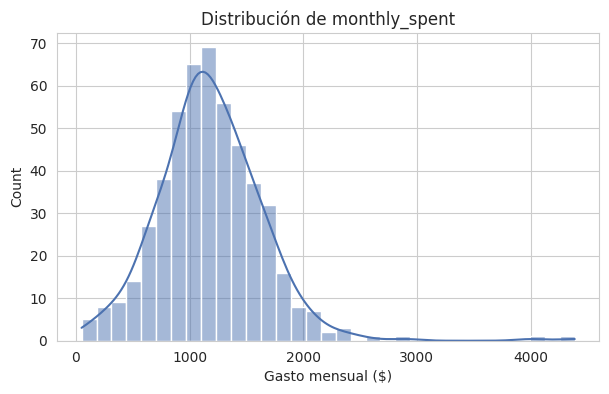

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df["monthly_spent"], kde=True, color="#4C72B0")
plt.title("Distribución de monthly_spent")
plt.xlabel("Gasto mensual ($)")
plt.show()

## 4. Distribución de las variables predictoras principales

Miramos también cómo se distribuyen las variables que probablemente usemos para predecir. Esto ayuda a detectar escalas muy distintas o sesgos fuertes.

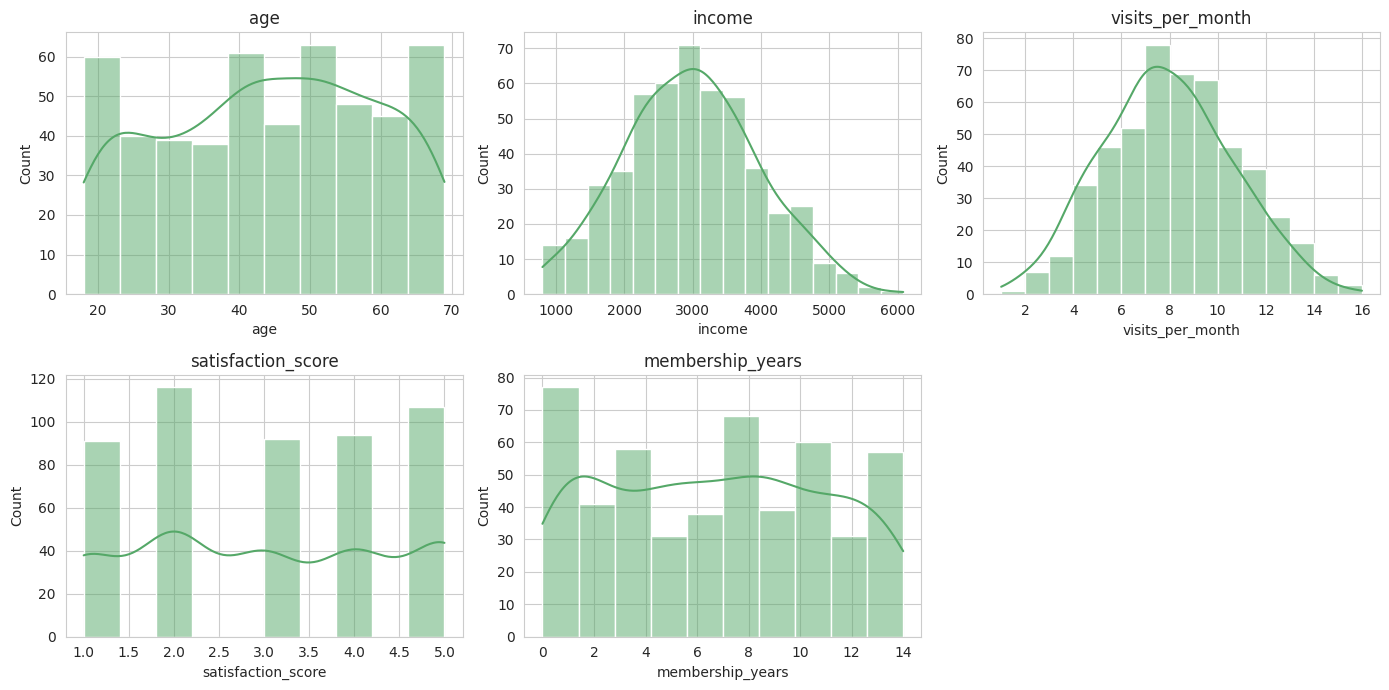

In [7]:
predictoras = ["age", "income", "visits_per_month", "satisfaction_score", "membership_years"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(predictoras):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#55A868")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 5. ¿Qué variable se relaciona más con el gasto?

Antes de elegir la variable para la regresión simple, conviene ver la correlación de cada predictora con `monthly_spent`. La que tenga mayor correlación es la mejor candidata para un modelo de una sola variable.

In [8]:
correlaciones = df[predictoras + ["monthly_spent"]].corr()["monthly_spent"].sort_values(ascending=False)
correlaciones

monthly_spent         1.000000
income                0.559534
membership_years      0.269133
satisfaction_score    0.211600
visits_per_month      0.041673
age                   0.005934
Name: monthly_spent, dtype: float64

`income` es, por lejos, la variable más correlacionada con el gasto mensual. Tiene sentido de negocio: a mayor ingreso, mayor capacidad de gasto. Por eso la usamos para el modelo simple.

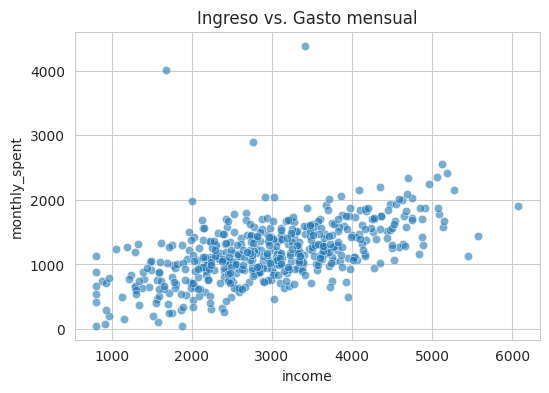

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="income", y="monthly_spent", alpha=0.6)
plt.title("Ingreso vs. Gasto mensual")
plt.show()

## 6. Separar en train y test

Para saber si el modelo generaliza (y no solo "memoriza" los datos que vio), separamos una parte de los datos que el modelo nunca va a ver durante el entrenamiento, y la usamos solo para evaluar al final.

In [10]:
X_simple = df[["income"]]
X_multiple = df[predictoras]
y = df["monthly_spent"]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

# Usamos el mismo split de filas (mismo random_state) para la versión múltiple,
# así los dos modelos se evalúan sobre exactamente los mismos clientes de test.
X_train_m, X_test_m, _, _ = train_test_split(
    X_multiple, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train_s.shape[0], "clientes | Test:", X_test_s.shape[0], "clientes")

Train: 400 clientes | Test: 100 clientes


## 7. Modelo 1 — Regresión lineal simple

Entrenamos un modelo que predice `monthly_spent` usando **una sola variable**: `income`. Es el punto de partida más simple posible para tener una referencia (baseline).

In [11]:
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train)

pred_simple = modelo_simple.predict(X_test_s)

print(f"Coeficiente (income): {modelo_simple.coef_[0]:.2f}")
print(f"Intercepto: {modelo_simple.intercept_:.2f}")

Coeficiente (income): 0.27
Intercepto: 365.78


## 8. Modelo 2 — Regresión lineal múltiple

Ahora usamos **todas** las variables predictoras disponibles (edad, ingreso, visitas, satisfacción, años de membresía). La idea es ver si sumar más información mejora la predicción respecto del modelo simple.

In [12]:
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train)

pred_multiple = modelo_multiple.predict(X_test_m)

coef_df = pd.DataFrame({
    "variable": predictoras,
    "coeficiente": modelo_multiple.coef_
}).sort_values("coeficiente", key=abs, ascending=False)
coef_df

,variable,coeficiente
3,satisfaction_score,71.498115
4,membership_years,21.940713
2,visits_per_month,14.754554
1,income,0.259377
0,age,0.081631


## 9. Evaluar los modelos en el conjunto de prueba

Para comparar los modelos de forma objetiva usamos tres métricas, todas calculadas **solo sobre el test** (datos que el modelo no vio al entrenar):

- **R²**: qué proporción de la variabilidad del gasto explica el modelo (más cerca de 1 es mejor).
- **MAE**: error promedio absoluto, en las mismas unidades que `monthly_spent` (dólares), fácil de interpretar.
- **RMSE**: parecido al MAE pero penaliza más los errores grandes.

In [13]:
def metricas(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

resultados = pd.DataFrame({
    "Regresión simple (income)": metricas(y_test, pred_simple),
    "Regresión múltiple": metricas(y_test, pred_multiple),
}).T

resultados.round(2)

,R2,MAE,RMSE
Regresión simple (income),0.22,273.41,435.06
Regresión múltiple,0.34,240.69,401.21


## 10. Gráfico: valores reales vs. predichos (extra)

Un buen modelo debería tener los puntos cerca de la diagonal (predicción = valor real). Esto nos da una idea visual rápida de qué tan bien ajusta el modelo múltiple.

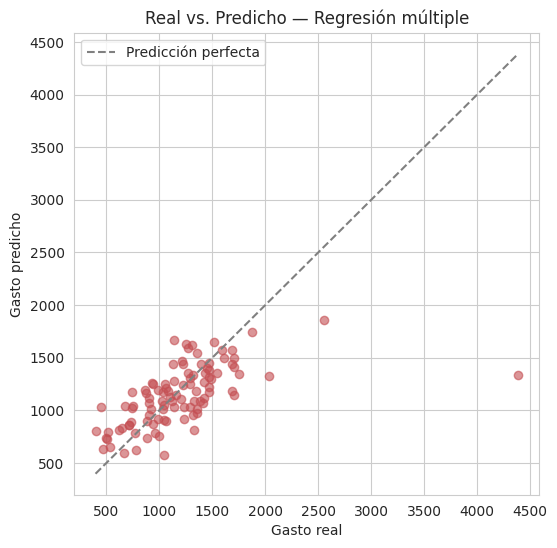

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_multiple, alpha=0.6, color="#C44E52")
lims = [min(y_test.min(), pred_multiple.min()), max(y_test.max(), pred_multiple.max())]
plt.plot(lims, lims, "--", color="gray", label="Predicción perfecta")
plt.xlabel("Gasto real")
plt.ylabel("Gasto predicho")
plt.title("Real vs. Predicho — Regresión múltiple")
plt.legend()
plt.show()

## 11. Conclusión

- La variable con mayor relación con el gasto mensual es **income**, lo cual tiene sentido de negocio.
- El modelo **simple** (solo income) ya explica una parte importante de la variabilidad del gasto.
- El modelo **múltiple** mejora al modelo simple (R² más alto y errores más bajos), porque suma información de visitas, satisfacción y antigüedad como cliente.
- El **MAE** del modelo múltiple indica, en dólares, cuánto se equivoca en promedio el modelo al predecir el gasto de un cliente — un error razonable para usar como referencia orientativa en decisiones de marketing, aunque no perfecto.
- **Próximo paso posible:** probar modelos no lineales (por ejemplo regresión polinómica) o sumar otras variables si RetailBoost las recolecta a futuro.